In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, welch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")
EPN_DIR = DATA_DIR / "epn612" / "raw"

FS = 200  # Hz, Myo armband sampling rate
GESTURES = ["noGesture", "open", "pinch", "waveOut", "fist", "waveIn"]
N_CHANNELS = 8

DRIFT_CUTOFF_HZ = 20.0
_highpass_sos = butter(4, DRIFT_CUTOFF_HZ, btype="highpass", fs=FS, output="sos")


def apply_highpass(x: np.ndarray) -> np.ndarray:
    """Zero-phase Butterworth high-pass (removes DC offset and sub-20Hz drift) --
    same SENIAM-convention filter used throughout this project's notebooks."""
    return sosfiltfilt(_highpass_sos, x, axis=-1)


def find_epn_user_files(root: Path, splits=("trainingJSON",), n=None):
    files = []
    for split in splits:
        files += sorted(
            root.rglob(f"{split}/user*/user*.json"),
            key=lambda p: int("".join(filter(str.isdigit, p.stem))),
        )
    return files if n is None else files[:n]


def samples_for_gesture(user_json: dict, gesture: str, n=None):
    out = []
    for split in ("trainingSamples", "testingSamples"):
        for sample in user_json.get(split, {}).values():
            if sample.get("gestureName") == gesture:
                out.append(sample["emg"])
                if n is not None and len(out) == n:
                    return out
    return out


def per_channel_features(x: np.ndarray) -> dict:
    """MAV + Fourier-domain features (Welch PSD), same trio used in
    epn612_crosstalk_causal_diagrams.ipynb -- kept identical so results here
    are directly comparable to that notebook's GFCI/ICP findings."""
    feats = {}
    feats["mav"] = np.mean(np.abs(x))
    nperseg = min(len(x), int(FS * 2.0))
    freqs, psd = welch(x, fs=FS, nperseg=nperseg)
    peak_idx = np.argmax(psd)
    feats["fft_peak_freq"] = freqs[peak_idx]
    feats["fft_mean_freq"] = np.sum(freqs * psd) / psd.sum()
    return feats


def load_wide_windows(splits=("trainingJSON",), n_users=None, trials_per_gesture=None):
    rows = []
    files = find_epn_user_files(EPN_DIR, splits=splits, n=n_users)
    for k, path in enumerate(files, 1):
        user_json = json.loads(path.read_text())
        age = user_json["userInfo"]["age"]
        uid = path.parent.name
        for gesture in GESTURES:
            for emg_dict in samples_for_gesture(user_json, gesture, trials_per_gesture):
                row = {"user": uid, "gesture": gesture, "age": age}
                for ch in range(1, N_CHANNELS + 1):
                    x = apply_highpass(np.array(emg_dict[f"ch{ch}"], dtype=float))
                    for name, value in per_channel_features(x).items():
                        row[f"ch{ch}_{name}"] = value
                rows.append(row)
        if k % 50 == 0 or k == len(files):
            print(f"  loaded {k}/{len(files)} users, {len(rows)} windows so far")
    return pd.DataFrame(rows)


wide_df = load_wide_windows(("trainingJSON",), n_users=None, trials_per_gesture=3)
FEATURE_COLS_WIDE = [c for c in wide_df.columns if c.startswith("ch") and ("mav" in c or "fft" in c)]
print(f"\n{wide_df.shape[0]} rows, {len(FEATURE_COLS_WIDE)} features, age range {wide_df['age'].min()}-{wide_df['age'].max()}")
wide_df.head()

  loaded 50/306 users, 900 windows so far
  loaded 100/306 users, 1800 windows so far
  loaded 150/306 users, 2700 windows so far
  loaded 200/306 users, 3600 windows so far
  loaded 250/306 users, 4500 windows so far
  loaded 300/306 users, 5400 windows so far
  loaded 306/306 users, 5508 windows so far

5508 rows, 24 features, age range 18-54


,user,gesture,age,ch1_mav,ch1_fft_peak_freq,ch1_fft_mean_freq,ch2_mav,ch2_fft_peak_freq,ch2_fft_mean_freq,ch3_mav,...,ch5_fft_mean_freq,ch6_mav,ch6_fft_peak_freq,ch6_fft_mean_freq,ch7_mav,ch7_fft_peak_freq,ch7_fft_mean_freq,ch8_mav,ch8_fft_peak_freq,ch8_fft_mean_freq
0,user1,noGesture,19,0.895392,72.5,63.454799,2.141860,69.5,65.528485,3.142480,...,62.722870,0.957900,88.0,62.268805,0.743140,91.5,60.436754,0.764259,88.5,60.697561
1,user1,noGesture,19,0.936866,87.0,60.532207,1.766218,68.0,61.803224,4.688319,...,64.008650,0.968333,73.0,60.045452,0.791993,88.0,61.995388,0.768542,82.0,61.913615
2,user1,noGesture,19,1.100648,45.0,62.922172,2.966961,91.0,64.009454,5.279161,...,60.165651,0.998615,29.5,62.335222,0.795677,76.5,59.992599,0.844713,90.0,62.737565
3,user1,open,19,2.536149,84.5,67.546129,8.608215,76.5,67.681557,6.887319,...,62.790041,1.933941,65.5,61.215896,1.967835,66.5,60.764028,3.952365,68.5,67.371262
4,user1,open,19,2.110451,70.5,69.443459,6.037057,88.0,66.892632,5.422287,...,64.941584,1.947802,87.0,69.948563,1.773373,83.0,69.633400,2.652607,67.0,60.070690


In [ ]:
import anchorboosting as ab
from sklearn.metrics import roc_auc_score, accuracy_score

FEATURE_COLS_ICP = [
    "ch1_mav", "ch2_mav", "ch3_mav", "ch4_fft_mean_freq", "ch5_fft_mean_freq",
    "ch5_mav", "ch6_mav", "ch7_mav", "ch8_mav",
]  


def age_group(age: int) -> str:
    if age < 25:
        return "18-25"
    elif age < 30:
        return "25-30"
    else:
        return "30+"


wide_df["age_group"] = wide_df["age"].apply(age_group)
train_mask = wide_df["age_group"] != "30+"
test_mask = wide_df["age_group"] == "30+"
print(f"train rows (18-25 + 25-30): {train_mask.sum()}, held-out test rows (30+): {test_mask.sum()}")

X_train_boost = wide_df.loc[train_mask, FEATURE_COLS_ICP]
X_test_boost = wide_df.loc[test_mask, FEATURE_COLS_ICP]
age_train_boost = wide_df.loc[train_mask, ["age"]].values.astype(float)

ACTIVE_GESTURES = [g for g in GESTURES if g != "noGesture"]  

boost_results = []
contrib_rows = []  
for gesture in ACTIVE_GESTURES:
    y_train = (wide_df.loc[train_mask, "gesture"] == gesture).astype(float).values
    y_test = (wide_df.loc[test_mask, "gesture"] == gesture).astype(float).values
    row = {"gesture": gesture}
    # Plain no importance to anchor variable
    # Robust importance to anchor variable
    for gamma, label in [(1, "plain"), (50, "robust")]:
        m = ab.AnchorBooster(gamma=gamma, objective="binary", num_boost_round=100,
                              max_depth=3, min_gain_to_split=0.1, learning_rate=0.1,
                              verbosity=-1)
        m.fit(X_train_boost, y_train, Z=age_train_boost)
        p_test = m.predict(X_test_boost)
        row[f"{label}_auc"] = roc_auc_score(y_test, p_test)
        row[f"{label}_acc"] = accuracy_score(y_test, p_test > 0.5)

        contrib = m.booster_.predict(X_test_boost, pred_contrib=True)[:, :-1]
        mean_contrib = contrib.mean(axis=0)
        for feat, c in zip(FEATURE_COLS_ICP, mean_contrib):
            contrib_rows.append({"gesture": gesture, "model": label, "feature": feat, "mean_contrib": c})
    boost_results.append(row)
    print(row, flush=True)

boost_results_df = pd.DataFrame(boost_results).set_index("gesture")
boost_results_df

train rows (18-25 + 25-30): 4806, held-out test rows (30+): 702


[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_id

{'gesture': 'open', 'plain_auc': 0.7693768719409745, 'plain_acc': 0.8347578347578347, 'robust_auc': 0.7687486302870917, 'robust_acc': 0.8361823361823362}


[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_id

{'gesture': 'pinch', 'plain_auc': 0.8541383592665643, 'plain_acc': 0.8561253561253561, 'robust_auc': 0.8589962743808897, 'robust_acc': 0.8603988603988604}


...

{'gesture': 'fist', 'plain_auc': 0.8985170574914164, 'plain_acc': 0.8660968660968661, 'robust_auc': 0.9008254803126597, 'robust_acc': 0.8703703703703703}


[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .

[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_id

{'gesture': 'waveIn', 'plain_auc': 0.884622689750895, 'plain_acc': 0.8646723646723646, 'robust_auc': 0.884184381620279, 'robust_acc': 0.8689458689458689}


[LightGBM] [Fatal] Check failed: leaf_idx >= 0 && leaf_idx < models_[tree_idx]->num_leaves() at /__w/1/s/lightgbm-python/src/boosting/gbdt.h, line 453 .



,plain_auc,plain_acc,robust_auc,robust_acc
gesture,,,,
open,0.769377,0.834758,0.768749,0.836182
pinch,0.854138,0.856125,0.858996,0.860399
waveOut,0.896106,0.893162,0.897845,0.894587
fist,0.898517,0.866097,0.900825,0.870370
waveIn,0.884623,0.864672,0.884184,0.868946


In [9]:
contrib_df = pd.DataFrame(contrib_rows)
contrib_pivot = contrib_df.pivot_table(index="feature", columns=["gesture", "model"], values="mean_contrib")
contrib_pivot = contrib_pivot[ACTIVE_GESTURES]  # keep the same gesture order used throughout
print("Mean signed SHAP-style contribution per feature (plain vs robust), per gesture:")
contrib_pivot.round(4)

Mean signed SHAP-style contribution per feature (plain vs robust), per gesture:


gesture              open           pinch         waveOut            fist  \
model               plain  robust   plain  robust   plain  robust   plain   
feature                                                                     
ch1_mav           -0.0043 -0.0067 -0.0417 -0.0648 -0.0565 -0.0381  0.0677   
ch2_mav            0.0316  0.0400  0.0448  0.0345  0.0212 -0.0059 -0.0815   
ch3_mav            0.0081  0.0067 -0.0248 -0.0173 -0.0030 -0.0172 -0.0122   
ch4_fft_mean_freq  0.0154  0.0187  0.0013  0.0067  0.0137  0.0145  0.0018   
ch5_fft_mean_freq -0.0034  0.0084  0.0224  0.0213  0.0378  0.0463  0.0450   
ch5_mav           -0.0214 -0.0316  0.0303  0.0298  0.0698  0.0590  0.0116   
ch6_mav           -0.0103 -0.0163  0.0088  0.0156  0.0190  0.0420  0.0191   
ch7_mav            0.0157  0.0248 -0.0403 -0.0323  0.0320  0.0249  0.0148   
ch8_mav           -0.0301 -0.0444  0.0470  0.0614  0.0171  0.0198  0.0533   

gesture                    waveIn          
model              robust   plain  robust  
feature                                    
ch1_mav            0.0993  0.0049 -0.0013  
ch2_mav           -0.0924  0.0179  0.0062  
ch3_mav           -0.0151 -0.0086  0.0063  
ch4_fft_mean_freq  0.0014 -0.0141 -0.0136  
ch5_fft_mean_freq  0.0449 -0.0444 -0.0474  
ch5_mav            0.0193 -0.0838 -0.0686  
ch6_mav            0.0101 -0.0175 -0.0198  
ch7_mav            0.0073 -0.0453 -0.0484  
ch8_mav            0.0443  0.0084  0.0073

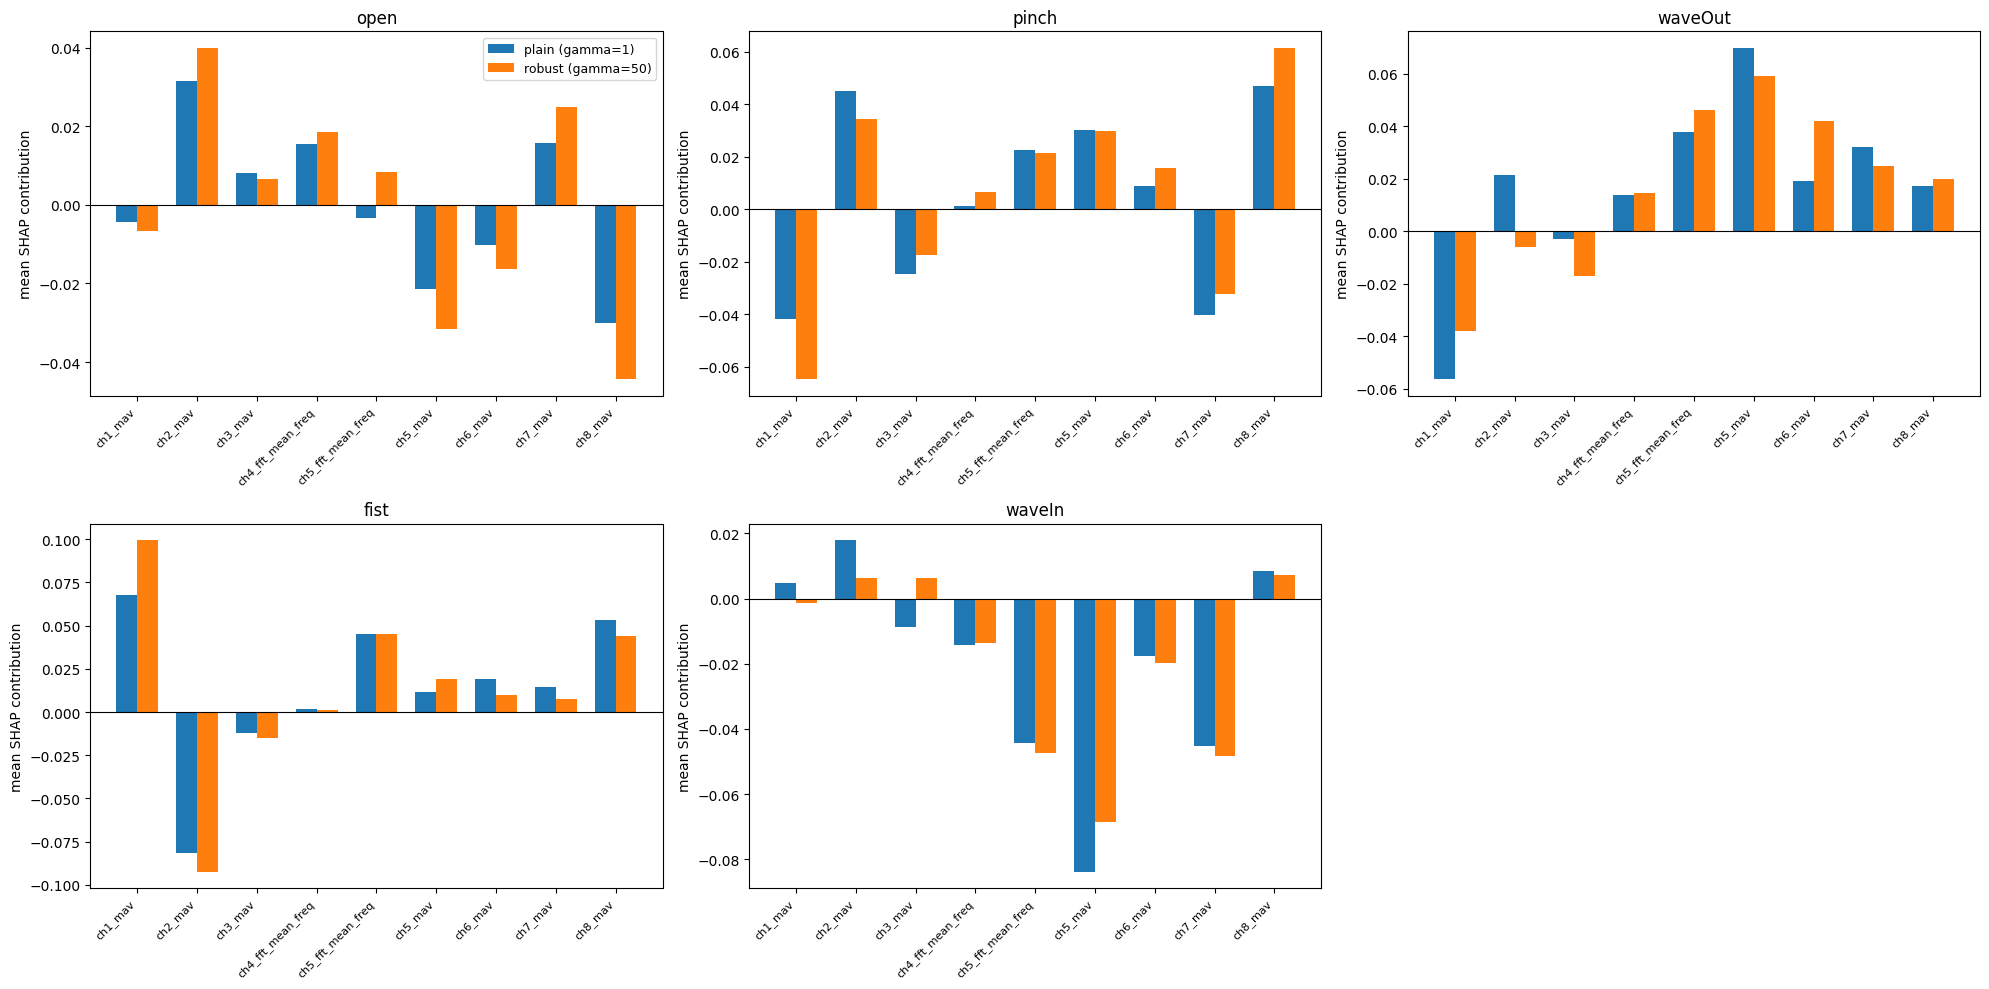

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, gesture in zip(axes.ravel(), ACTIVE_GESTURES):
    sub = contrib_df[contrib_df["gesture"] == gesture].pivot(index="feature", columns="model", values="mean_contrib")
    sub = sub.reindex(FEATURE_COLS_ICP)[["plain", "robust"]]
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width / 2, sub["plain"], width, label="plain (gamma=1)")
    ax.bar(x + width / 2, sub["robust"], width, label="robust (gamma=50)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(gesture)
    ax.set_ylabel("mean SHAP contribution")

for ax in axes.ravel()[len(ACTIVE_GESTURES):]:
    ax.axis("off")
axes.ravel()[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

In [11]:
shift_rows = []
for gesture in ACTIVE_GESTURES:
    for feat in FEATURE_COLS_ICP:
        p = contrib_df.query("gesture == @gesture and model == 'plain' and feature == @feat")["mean_contrib"].iloc[0]
        r = contrib_df.query("gesture == @gesture and model == 'robust' and feature == @feat")["mean_contrib"].iloc[0]
        shift_rows.append({"feature": feat, "abs_shift": abs(r - p)})

shift_df = pd.DataFrame(shift_rows).groupby("feature")["abs_shift"].mean().sort_values()
print("Mean |robust - plain| contribution shift, averaged across the 5 gestures "
      "(lower = more stable under anchoring):")
print(shift_df)

Mean |robust - plain| contribution shift, averaged across the 5 gestures (lower = more stable under anchoring):
feature
ch4_fft_mean_freq    0.002076
ch5_fft_mean_freq    0.004896
ch7_mav              0.006961
ch3_mav              0.008196
ch8_mav              0.008295
ch5_mav              0.008905
ch6_mav              0.009393
ch2_mav              0.013705
ch1_mav              0.016348
Name: abs_shift, dtype: float64
